<a href="https://colab.research.google.com/github/mpate154/BTT_Final_ML_Project/blob/main/WiBS_FCMData.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#@title uploader
file_id = "1VpSCc_ms2dj59bMAAOqCu0OI0jjb-8Hq" #@param {type:"string"}
!pip install -U -q PyDrive

from pydrive.auth import GoogleAuth
from pydrive.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

# 1. Authenticate and create the PyDrive client.
auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

# PyDrive reference:
# https://googledrive.github.io/PyDrive/docs/build/html/index.html


from google.colab import auth
auth.authenticate_user()

from googleapiclient.discovery import build
drive_service = build('drive', 'v3')

# Replace the assignment below with your file ID
# to download a different file.
#
# A file ID looks like: 1gLBqEWEBQDYbKCDigHnUXNTkzl-OslSO

import io
from googleapiclient.http import MediaIoBaseDownload

request = drive_service.files().get_media(fileId=file_id)
downloaded = io.BytesIO()
downloader = MediaIoBaseDownload(downloaded, request)
done = False
while done is False:
  # _ is a placeholder for a progress object that we ignore.
  # (Our file is small, so we skip reporting progress.)
  _, done = downloader.next_chunk()

fileId = drive.CreateFile({'id': file_id }) #DRIVE_FILE_ID is file id example: 1iytA1n2z4go3uVCwE_vIKouTKyIDjEq
print(fileId['title'])
fileId.GetContentFile(fileId['title'])  # Save Drive file as a local file

!unzip {fileId['title']}

widsdatathon2025.zip
Archive:  widsdatathon2025.zip
  inflating: Data Dictionary.xlsx    
  inflating: SAMPLE_SUBMISSION.xlsx  
  inflating: TEST/TEST_CATEGORICAL.xlsx  
  inflating: TEST/TEST_FUNCTIONAL_CONNECTOME_MATRICES.csv  
  inflating: TEST/TEST_QUANTITATIVE_METADATA.xlsx  
  inflating: TRAIN/TRAINING_SOLUTIONS.xlsx  
  inflating: TRAIN/TRAIN_CATEGORICAL_METADATA.xlsx  
  inflating: TRAIN/TRAIN_FUNCTIONAL_CONNECTOME_MATRICES.csv  
  inflating: TRAIN/TRAIN_QUANTITATIVE_METADATA.xlsx  


## Data Prep

In [2]:
# I don't have this package so I'm installing it. If the cell below doesn't work
# for you, you might have to run this before.
!pip install geomstats

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 7.4 MB/s eta 0:00:00


In [3]:
import geomstats.datasets.utils as data_utils
import pandas as pd
import numpy as np

INFO:numexpr.utils:NumExpr defaulting to 2 threads.


In [4]:
fcm = pd.read_csv("TRAIN/TRAIN_FUNCTIONAL_CONNECTOME_MATRICES.csv")
fcm_solutions = pd.read_excel("TRAIN/TRAINING_SOLUTIONS.xlsx")

In [ ]:
fcm.shape

(1213, 19901)

In [5]:
fcm.describe()

,0throw_1thcolumn,0throw_2thcolumn,0throw_3thcolumn,0throw_4thcolumn,0throw_5thcolumn,0throw_6thcolumn,0throw_7thcolumn,0throw_8thcolumn,0throw_9thcolumn,0throw_10thcolumn,...,195throw_196thcolumn,195throw_197thcolumn,195throw_198thcolumn,195throw_199thcolumn,196throw_197thcolumn,196throw_198thcolumn,196throw_199thcolumn,197throw_198thcolumn,197throw_199thcolumn,198throw_199thcolumn
count,1213.000000,1213.000000,1213.000000,1213.000000,1213.000000,1213.000000,1213.000000,1213.000000,1213.000000,1213.000000,...,1213.000000,1213.000000,1213.000000,1213.000000,1213.000000,1213.000000,1213.000000,1213.000000,1213.000000,1213.000000
mean,0.060553,0.122315,0.060268,0.041287,0.069722,0.091007,0.066852,0.000252,0.014128,-0.002914,...,0.011075,-0.004938,-0.004378,0.001610,0.115171,0.049984,0.058144,0.093527,0.089403,0.128946
std,0.064178,0.054026,0.057495,0.043491,0.044222,0.049189,0.046864,0.049046,0.038205,0.042462,...,0.049632,0.046536,0.042900,0.047424,0.057128,0.051664,0.057674,0.054594,0.058036,0.058490
min,-0.183279,-0.059932,-0.145566,-0.127827,-0.072043,-0.079184,-0.105722,-0.164297,-0.137728,-0.148490,...,-0.161666,-0.176523,-0.178688,-0.138048,-0.070094,-0.153540,-0.131455,-0.085566,-0.204160,-0.083077
25%,0.018482,0.086102,0.026548,0.014457,0.042462,0.057614,0.036934,-0.031358,-0.010635,-0.030538,...,-0.021376,-0.033424,-0.033798,-0.030132,0.080291,0.015827,0.022316,0.059621,0.053224,0.090459
50%,0.058276,0.123220,0.061339,0.043246,0.067066,0.086494,0.067247,0.002549,0.016130,-0.002604,...,0.010254,-0.004683,-0.003724,0.000990,0.113640,0.052705,0.059151,0.093397,0.088612,0.127913
75%,0.100103,0.154518,0.099056,0.068408,0.096504,0.119404,0.095117,0.031053,0.038770,0.024507,...,0.044165,0.024913,0.024007,0.032268,0.150524,0.082526,0.095192,0.127144,0.127613,0.166523
max,0.321522,0.390895,0.278429,0.189825,0.317500,0.316811,0.270018,0.168196,0.145364,0.128301,...,0.194616,0.183152,0.180562,0.192015,0.375635,0.228748,0.322084,0.348153,0.267162,0.414304


In [ ]:
fcm.isnull().sum().sum()

0

In [ ]:
fcm.head()

,participant_id,0throw_1thcolumn,0throw_2thcolumn,0throw_3thcolumn,0throw_4thcolumn,0throw_5thcolumn,0throw_6thcolumn,0throw_7thcolumn,0throw_8thcolumn,0throw_9thcolumn,...,195throw_196thcolumn,195throw_197thcolumn,195throw_198thcolumn,195throw_199thcolumn,196throw_197thcolumn,196throw_198thcolumn,196throw_199thcolumn,197throw_198thcolumn,197throw_199thcolumn,198throw_199thcolumn
0,70z8Q2xdTXM3,0.093473,0.146902,0.067893,0.015141,0.070221,0.063997,0.055382,-0.035335,0.068583,...,0.003404,-0.010359,-0.050968,-0.014365,0.128066,0.112646,-0.058980,0.028228,0.133582,0.143372
1,WHWymJu6zNZi,0.029580,0.179323,0.112933,0.038291,0.104899,0.064250,0.008488,0.077505,-0.004750,...,-0.008409,-0.008479,0.020891,0.017754,0.094040,0.035141,0.032537,0.075007,0.115350,0.138200
2,4PAQp1M6EyAo,-0.051580,0.139734,0.068295,0.046991,0.111085,0.026978,0.151377,0.021198,0.083721,...,0.053245,-0.028003,0.028773,0.024556,0.166343,0.058925,0.035485,0.063661,0.042862,0.162162
3,obEacy4Of68I,0.016273,0.204702,0.115980,0.043103,0.056431,0.057615,0.055773,0.075030,0.001033,...,-0.023918,-0.005356,0.018607,0.016193,0.072955,0.130135,0.056120,0.084784,0.114148,0.190584
4,s7WzzDcmDOhF,0.065771,0.098714,0.097604,0.112988,0.071139,0.085607,0.019392,-0.036403,-0.020375,...,0.066439,-0.076680,-0.047530,-0.031443,0.221213,0.007343,0.005763,0.083820,0.079582,0.067269


I was going to graph below, but each participants fcms need to be a numpy array for this to work so it doesn't run for now.

In [10]:
graph_fcm = fcm.merge(fcm_solutions, on="participant_id")
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:

# Example data
# Assume `matrices` is a list of connectivity matrices (2D arrays) for all individuals
# Assume `labels` is a list of binary labels (0 or 1) corresponding to each individual

# Separate matrices into two groups based on labels
group_0 = [graph_fcm[i] for i in range(len(graph_fcm)) if graph_fcm.ADHD_Outcome[i] == 0]
group_1 = [graph_fcm[i] for i in range(len(graph_fcm)) if graph_fcm.ADHD_Outcome[i] == 1]

# Compute average connectivity matrices for each group
avg_matrix_0 = np.mean(group_0, axis=0)
avg_matrix_1 = np.mean(group_1, axis=0)

# Visualize the average matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot group 0
sns.heatmap(avg_matrix_0, ax=axes[0], cmap="coolwarm", vmin=0, vmax=1, square=True, cbar=True)
axes[0].set_title("Group 0 (Label = 0)")

# Plot group 1
sns.heatmap(avg_matrix_1, ax=axes[1], cmap="coolwarm", vmin=0, vmax=1, square=True, cbar=True)
axes[1].set_title("Group 1 (Label = 1)")

plt.tight_layout()
plt.show()

# Optional: Compute and visualize the difference between the two groups
difference_matrix = avg_matrix_1 - avg_matrix_0

plt.figure(figsize=(6, 6))
sns.heatmap(difference_matrix, cmap="coolwarm", center=0, square=True, cbar=True)
plt.title("Difference (Group 1 - Group 0)")
plt.show()

In [ ]:
graph_fcm.columns

Index(['participant_id', '0throw_1thcolumn', '0throw_2thcolumn',
       '0throw_3thcolumn', '0throw_4thcolumn', '0throw_5thcolumn',
       '0throw_6thcolumn', '0throw_7thcolumn', '0throw_8thcolumn',
       '0throw_9thcolumn',
       ...
       '195throw_198thcolumn', '195throw_199thcolumn', '196throw_197thcolumn',
       '196throw_198thcolumn', '196throw_199thcolumn', '197throw_198thcolumn',
       '197throw_199thcolumn', '198throw_199thcolumn', 'ADHD_Outcome',
       'Sex_F'],
      dtype='object', length=19903)

In [ ]:
print(graph_fcm.isna().sum().sum()) #sum of missing values along all cols. shld be zero.

0


<h2> Data Exploration </h2>

Doesn't seem to be missing any values. Checking the distribution of ADHD_Outcome and Sex_F.

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


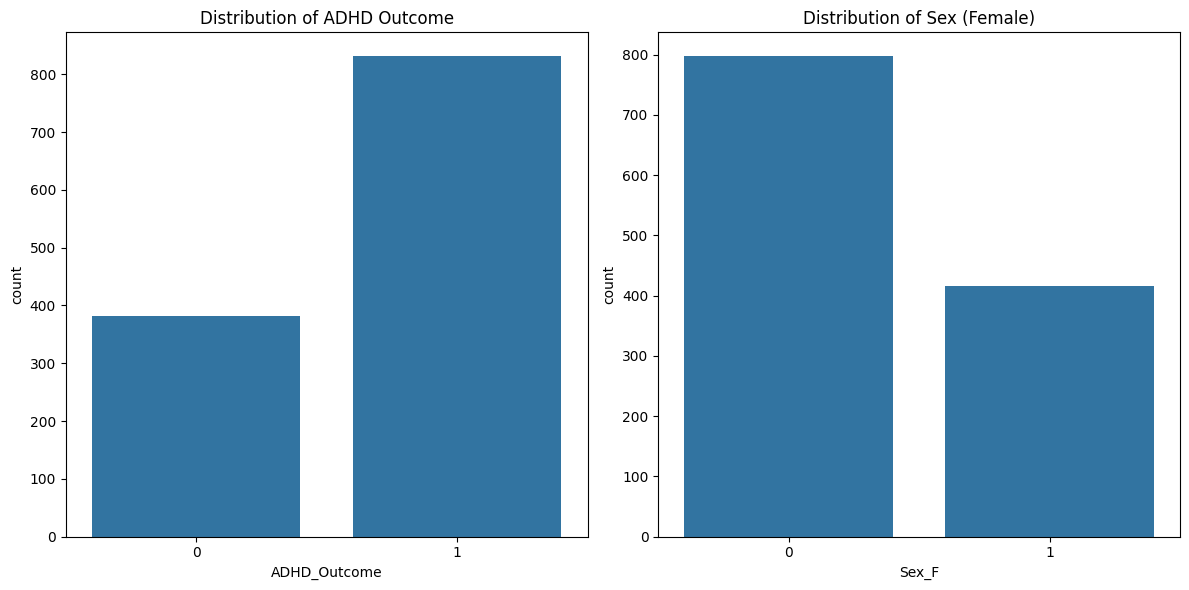

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.countplot(x='ADHD_Outcome', data=graph_fcm)
plt.title('Distribution of ADHD Outcome')

plt.subplot(1, 2, 2)
sns.countplot(x='Sex_F', data=graph_fcm)
plt.title('Distribution of Sex (Female)')

plt.tight_layout()
plt.show()


Ok looks like there is still way more male ADHD data than female. We can consider training on only the female if the accuracy is bad there. Now graphing the average connectivity of the matrices

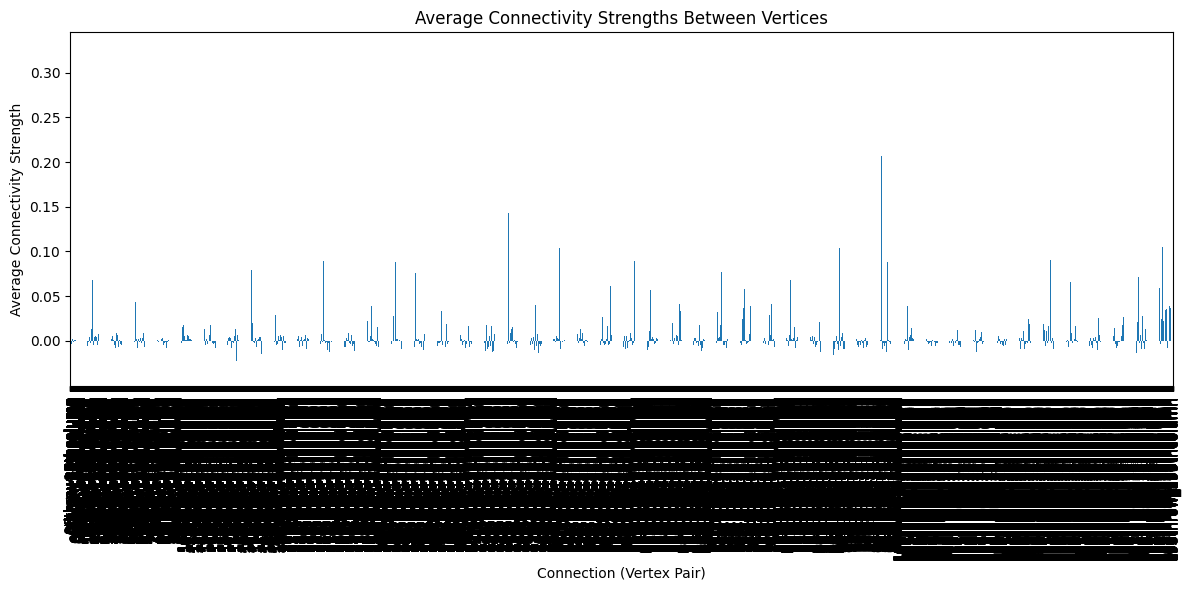

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract connectivity strength columns (excluding participant_id and ADHD_Outcome)
connectivity_columns = [col for col in graph_fcm.columns if col not in ['participant_id', 'ADHD_Outcome', 'Sex_F']]

# Calculate the average connectivity strength for each connection
average_connectivity = graph_fcm[connectivity_columns].mean()

# Create the plot
plt.figure(figsize=(12, 6))
average_connectivity.plot(kind='bar')
plt.xlabel('Connection (Vertex Pair)')
plt.ylabel('Average Connectivity Strength')
plt.title('Average Connectivity Strengths Between Vertices')
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()


<h2> FCM Graph Neural Network </h2>
AKA the hard part. Having a hard time keeping it from crashing; should follow the example architecture very carefully because we're dealing with a lot of data.

In [6]:
pip install torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 84.9 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [8]:
pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 56.2 MB/s eta 0:00:00


<h2> warning - do not run the below cell it will crash the gpu </h2>

In [ ]:

import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data

# Assuming 'graph_fcm' DataFrame is already loaded and preprocessed

# Remove 'Sex_F' column
graph_fcm = graph_fcm.drop('Sex_F', axis=1)

# Prepare data for PyTorch Geometric
# Assuming 'connectivity_columns' contains the column names of connectivity features
connectivity_columns = [col for col in graph_fcm.columns if col not in ['participant_id', 'ADHD_Outcome']]
features = graph_fcm[connectivity_columns].values
labels = graph_fcm['ADHD_Outcome'].values

# Create an adjacency matrix (replace with actual adjacency if available)
# For now, using a fully connected graph as a placeholder
num_nodes = features.shape[1]
adjacency_matrix = np.ones((num_nodes, num_nodes))
np.fill_diagonal(adjacency_matrix, 0) #no self loops

# Create a PyTorch Geometric Data object
data = Data(x=torch.tensor(features, dtype=torch.float32),
            edge_index=torch.tensor(np.array(np.where(adjacency_matrix)), dtype=torch.long),
            y=torch.tensor(labels, dtype=torch.long))


class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)


# Hyperparameters
in_channels = data.num_node_features
hidden_channels = 64
out_channels = 2  # Two classes: ADHD (1) and no ADHD (0)
learning_rate = 0.01
epochs = 200

# Model, optimizer and loss
model = GCN(in_channels, hidden_channels, out_channels)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
criterion = torch.nn.CrossEntropyLoss()

# Train the model
model.train()
for epoch in range(epochs):
  optimizer.zero_grad()
  out = model(data.x, data.edge_index)
  loss = criterion(out, data.y)
  loss.backward()
  optimizer.step()
  if epoch % 50 == 0:
    print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

# Evaluation (placeholder - replace with proper evaluation metrics)
model.eval()
_, pred = model(data.x, data.edge_index).max(dim=1)
correct = float(pred.eq(data.y).sum().item())
acc = correct / len(data.y)
print(f"Accuracy: {acc:.4f}")


## **Summary of below cells**

Can't seem to better than 0.6851

### Google Collab Code

Aka runnable version of above code

| Label | Accuracy |
|-------|----------|
| ADHD  | 0.6851   |
|Sex_F  | 0.6570   |

### Class Weights to Minority

| Label | Accuracy |
|-------|----------|
| ADHD  | 0.5      |


### SMOTE - Oversampling minority


| Label | Accuracy |
|-------|----------|
| ADHD  | 0.5      |
|Sex_F  | 0.5      |

### Different GCN

| Label | Accuracy | Learning Rate |
|-------|----------|---------------|
| ADHD  | 0.6851   | 0.01          |
| ADHD  | 0.6851   | 0.05          |




## Google Collab Running Code
^^ Version of this that can run on collab

Both have such high losses they are randomly guessing so.

Predicting ADHD

In [21]:
#reset graph_fcm before running below cell
graph_fcm = fcm.merge(fcm_solutions, on="participant_id")

In [22]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data
import numpy as np  # Ensure NumPy is imported

# Check if GPU is available and set the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Assuming 'graph_fcm' DataFrame is already loaded and preprocessed
# Remove 'Sex_F' column
graph_fcm = graph_fcm.drop('Sex_F', axis=1)

# Prepare data for PyTorch Geometric
connectivity_columns = [col for col in graph_fcm.columns if col not in ['participant_id', 'ADHD_Outcome']]
features = graph_fcm[connectivity_columns].values
labels = graph_fcm['ADHD_Outcome'].values

# Create an adjacency matrix (replace with actual adjacency if available)
num_nodes = features.shape[0]  # Ensure correct shape (number of samples, not features)
adjacency_matrix = np.ones((num_nodes, num_nodes))
np.fill_diagonal(adjacency_matrix, 0)  # No self-loops

# Convert to PyTorch tensors and move to device
data = Data(
    x=torch.tensor(features, dtype=torch.float32).to(device),
    edge_index=torch.tensor(np.array(np.where(adjacency_matrix)), dtype=torch.long).to(device),
    y=torch.tensor(labels, dtype=torch.long).to(device)
)


class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)


# Hyperparameters
in_channels = data.num_features
hidden_channels = 64
out_channels = 2  # Two classes: ADHD (1) and no ADHD (0)
learning_rate = 0.01
epochs = 200

# Model, optimizer, and loss function
model_adhd = GCN(in_channels, hidden_channels, out_channels).to(device)
optimizer = torch.optim.Adam(model_adhd.parameters(), lr=learning_rate)
criterion = torch.nn.CrossEntropyLoss()

# Train the model
model_adhd.train()
for epoch in range(epochs):
    optimizer.zero_grad()
    out = model_adhd(data.x, data.edge_index)
    loss = criterion(out, data.y)
    loss.backward()
    optimizer.step()

    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

# Evaluation
model_adhd.eval()
_, pred = model_adhd(data.x, data.edge_index).max(dim=1)
correct = float(pred.eq(data.y).sum().item())
acc = correct / len(data.y)
print(f"Accuracy: {acc:.4f}")


Using device: cuda
Epoch 0, Loss: 0.6911
Epoch 50, Loss: 0.6272
Epoch 100, Loss: 0.6230
Epoch 150, Loss: 0.6230
Accuracy: 0.6851


Predicting Sex_F with same model as above

In [31]:
#reset graph_fcm before running below cell
graph_fcm = fcm.merge(fcm_solutions, on="participant_id")

In [32]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data
import numpy as np  # Ensure NumPy is imported

# Check if GPU is available and set the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Assuming 'graph_fcm' DataFrame is already loaded and preprocessed
# Remove 'Sex_F' column
graph_fcm = graph_fcm.drop('ADHD_Outcome', axis=1)

# Prepare data for PyTorch Geometric
connectivity_columns = [col for col in graph_fcm.columns if col not in ['participant_id', 'Sex_F']]
features = graph_fcm[connectivity_columns].values
labels = graph_fcm['Sex_F'].values

# Create an adjacency matrix (replace with actual adjacency if available)
num_nodes = features.shape[0]  # Ensure correct shape (number of samples, not features)
adjacency_matrix = np.ones((num_nodes, num_nodes))
np.fill_diagonal(adjacency_matrix, 0)  # No self-loops

# Convert to PyTorch tensors and move to device
data = Data(
    x=torch.tensor(features, dtype=torch.float32).to(device),
    edge_index=torch.tensor(np.array(np.where(adjacency_matrix)), dtype=torch.long).to(device),
    y=torch.tensor(labels, dtype=torch.long).to(device)
)


class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)


# Hyperparameters
in_channels = data.num_features
hidden_channels = 64
out_channels = 2  # Two classes: ADHD (1) and no ADHD (0)
learning_rate = 0.01
epochs = 200

# Model, optimizer, and loss function
model_f = GCN(in_channels, hidden_channels, out_channels).to(device)
optimizer = torch.optim.Adam(model_f.parameters(), lr=learning_rate)
criterion = torch.nn.CrossEntropyLoss()

# Train the model
model_f.train()
for epoch in range(epochs):
    optimizer.zero_grad()
    out = model_f(data.x, data.edge_index)
    loss = criterion(out, data.y)
    loss.backward()
    optimizer.step()

    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

# Evaluation
model_f.eval()
_, pred = model_f(data.x, data.edge_index).max(dim=1)
correct = float(pred.eq(data.y).sum().item())
acc = correct / len(data.y)
print(f"Accuracy: {acc:.4f}")


Using device: cuda
Epoch 0, Loss: 0.6920
Epoch 50, Loss: 0.6448
Epoch 100, Loss: 0.6430
Epoch 150, Loss: 0.6430
Accuracy: 0.6570


## Adding Class Weights to Above Models

To add more weight to minority classes (female and non-adhd) to see if it improves model accuracy because without it, the testing model just guessed not female and has adhd for every participant ;,(

### ADHD_Outcome

Basically same outcome so i didn't try it on Sex_f

In [37]:
#reset graph_fcm before running below cell
graph_fcm = fcm.merge(fcm_solutions, on="participant_id")

import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data
import numpy as np  # Ensure NumPy is imported
from sklearn.utils.class_weight import compute_class_weight #for weightsi

# Check if GPU is available and set the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Assuming 'graph_fcm' DataFrame is already loaded and preprocessed
# Remove 'Sex_F' column
graph_fcm = graph_fcm.drop('Sex_F', axis=1)

# Prepare data for PyTorch Geometric
connectivity_columns = [col for col in graph_fcm.columns if col not in ['participant_id', 'ADHD_Outcome']]
features = graph_fcm[connectivity_columns].values
labels = graph_fcm['ADHD_Outcome'].values

# Create an adjacency matrix (replace with actual adjacency if available)
num_nodes = features.shape[0]  # Ensure correct shape (number of samples, not features)
adjacency_matrix = np.ones((num_nodes, num_nodes))
np.fill_diagonal(adjacency_matrix, 0)  # No self-loops

# Convert to PyTorch tensors and move to device
data = Data(
    x=torch.tensor(features, dtype=torch.float32).to(device),
    edge_index=torch.tensor(np.array(np.where(adjacency_matrix)), dtype=torch.long).to(device),
    y=torch.tensor(labels, dtype=torch.long).to(device)
)


class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)


# Hyperparameters
in_channels = data.num_features
hidden_channels = 64
out_channels = 2  # Two classes: ADHD (1) and no ADHD (0)
learning_rate = 0.01
epochs = 200

#Weights
#compute weights
labels_np = labels.astype(int)
class_weights = compute_class_weight('balanced', classes=np.unique(labels_np), y=labels_np)
#convert to pytorch tensor and move to device
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

# Model, optimizer, and loss function
model_adhd = GCN(in_channels, hidden_channels, out_channels).to(device)
optimizer = torch.optim.Adam(model_adhd.parameters(), lr=learning_rate)
criterion = torch.nn.CrossEntropyLoss(weight=class_weights) #add argument to this to account for weights

# Train the model
model_adhd.train()
for epoch in range(epochs):
    optimizer.zero_grad()
    out = model_adhd(data.x, data.edge_index)
    loss = criterion(out, data.y)
    loss.backward()
    optimizer.step()

    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

# Evaluation
model_adhd.eval()
_, pred = model_adhd(data.x, data.edge_index).max(dim=1)
correct = float(pred.eq(data.y).sum().item())
acc = correct / len(data.y)
print(f"Accuracy: {acc:.4f}")


Using device: cuda
Epoch 0, Loss: 0.6932
Epoch 50, Loss: 0.6932
Epoch 100, Loss: 0.6931
Epoch 150, Loss: 0.6931
Accuracy: 0.6851


## Using oversampling of minority class

Using SMOTE (Synthetic Minority Over-sampling Technique)

ADHD outcome

50% is worse bruh

In [39]:
#reset graph_fcm before running below cell
graph_fcm = fcm.merge(fcm_solutions, on="participant_id")

import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data
import numpy as np  # Ensure NumPy is imported

# Check if GPU is available and set the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Assuming 'graph_fcm' DataFrame is already loaded and preprocessed
# Remove 'Sex_F' column
graph_fcm = graph_fcm.drop('Sex_F', axis=1)

# Prepare data for PyTorch Geometric
connectivity_columns = [col for col in graph_fcm.columns if col not in ['participant_id', 'ADHD_Outcome']]
features = graph_fcm[connectivity_columns].values
labels = graph_fcm['ADHD_Outcome'].values

########### BALANCING MINORITIES ###############
# identifying minority class in tester (no ADHD is minority in training, might not be for tester but i doubt it, but we'll check anyways)
minority_class = 0 if np.sum(labels == 1) > np.sum(labels == 0) else 1

minority_indices = np.where(labels == minority_class)[0]
majority_indices = np.where(labels != minority_class)[0]

#ovesample minority bu duplicating them
num_minority_needed = len(majority_indices) - len(minority_indices)
oversampled_minority_indices = np.random.choice(minority_indices, num_minority_needed, replace=True)

#combine all new duplicated min. with original where minority and majority class are balanced
balanced_indices = np.concatenate([majority_indices, minority_indices, oversampled_minority_indices])

# get new features and labels
features_balanced = features[balanced_indices]
labels_balanced = labels[balanced_indices]

#################################################
# Create an adjacency matrix (replace with actual adjacency if available)
num_nodes = features_balanced.shape[0]  # CHANGED TO FATURED_BALANCED // Ensure correct shape (number of samples, not features)
adjacency_matrix = np.ones((num_nodes, num_nodes))
np.fill_diagonal(adjacency_matrix, 0)  # No self-loops

# Convert to PyTorch tensors and move to device (change to featured_balanced)
data = Data(
    x=torch.tensor(features_balanced, dtype=torch.float32).to(device),
    edge_index=torch.tensor(np.array(np.where(adjacency_matrix)), dtype=torch.long).to(device),
    y=torch.tensor(labels_balanced, dtype=torch.long).to(device)
)


class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)


# Hyperparameters
in_channels = data.num_features
hidden_channels = 64
out_channels = 2  # Two classes: ADHD (1) and no ADHD (0)
learning_rate = 0.01
epochs = 200


# Model, optimizer, and loss function
model_adhd = GCN(in_channels, hidden_channels, out_channels).to(device)
optimizer = torch.optim.Adam(model_adhd.parameters(), lr=learning_rate)
criterion = torch.nn.CrossEntropyLoss()

# Train the model
model_adhd.train()
for epoch in range(epochs):
    optimizer.zero_grad()
    out = model_adhd(data.x, data.edge_index)
    loss = criterion(out, data.y)
    loss.backward()
    optimizer.step()

    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

# Evaluation
model_adhd.eval()
_, pred = model_adhd(data.x, data.edge_index).max(dim=1)
correct = float(pred.eq(data.y).sum().item())
acc = correct / len(data.y)
print(f"Accuracy: {acc:.4f}")


Using device: cuda
Epoch 0, Loss: 0.6932
Epoch 50, Loss: 0.6931
Epoch 100, Loss: 0.6931
Epoch 150, Loss: 0.6931
Accuracy: 0.5000


Sex_f bc why not

same result

In [40]:
#reset graph_fcm before running below cell
graph_fcm = fcm.merge(fcm_solutions, on="participant_id")

import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data
import numpy as np  # Ensure NumPy is imported

# Check if GPU is available and set the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Assuming 'graph_fcm' DataFrame is already loaded and preprocessed
# Remove 'Sex_F' column
graph_fcm = graph_fcm.drop('ADHD_Outcome', axis=1)

# Prepare data for PyTorch Geometric
connectivity_columns = [col for col in graph_fcm.columns if col not in ['participant_id', 'Sex_F']]
features = graph_fcm[connectivity_columns].values
labels = graph_fcm['Sex_F'].values

########### BALANCING MINORITIES ###############
# identifying minority class in tester (no ADHD is minority in training, might not be for tester but i doubt it, but we'll check anyways)
minority_class = 0 if np.sum(labels == 1) > np.sum(labels == 0) else 1

minority_indices = np.where(labels == minority_class)[0]
majority_indices = np.where(labels != minority_class)[0]

#ovesample minority bu duplicating them
num_minority_needed = len(majority_indices) - len(minority_indices)
oversampled_minority_indices = np.random.choice(minority_indices, num_minority_needed, replace=True)

#combine all new duplicated min. with original where minority and majority class are balanced
balanced_indices = np.concatenate([majority_indices, minority_indices, oversampled_minority_indices])

# get new features and labels
features_balanced = features[balanced_indices]
labels_balanced = labels[balanced_indices]

#################################################
# Create an adjacency matrix (replace with actual adjacency if available)
num_nodes = features_balanced.shape[0]  # CHANGED TO FATURED_BALANCED // Ensure correct shape (number of samples, not features)
adjacency_matrix = np.ones((num_nodes, num_nodes))
np.fill_diagonal(adjacency_matrix, 0)  # No self-loops

# Convert to PyTorch tensors and move to device (change to featured_balanced)
data = Data(
    x=torch.tensor(features_balanced, dtype=torch.float32).to(device),
    edge_index=torch.tensor(np.array(np.where(adjacency_matrix)), dtype=torch.long).to(device),
    y=torch.tensor(labels_balanced, dtype=torch.long).to(device)
)


class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)


# Hyperparameters
in_channels = data.num_features
hidden_channels = 64
out_channels = 2  # Two classes: ADHD (1) and no ADHD (0)
learning_rate = 0.01
epochs = 200


# Model, optimizer, and loss function
model_adhd = GCN(in_channels, hidden_channels, out_channels).to(device)
optimizer = torch.optim.Adam(model_adhd.parameters(), lr=learning_rate)
criterion = torch.nn.CrossEntropyLoss()

# Train the model
model_adhd.train()
for epoch in range(epochs):
    optimizer.zero_grad()
    out = model_adhd(data.x, data.edge_index)
    loss = criterion(out, data.y)
    loss.backward()
    optimizer.step()

    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

# Evaluation
model_adhd.eval()
_, pred = model_adhd(data.x, data.edge_index).max(dim=1)
correct = float(pred.eq(data.y).sum().item())
acc = correct / len(data.y)
print(f"Accuracy: {acc:.4f}")


Using device: cuda
Epoch 0, Loss: 0.6935
Epoch 50, Loss: 0.6932
Epoch 100, Loss: 0.6931
Epoch 150, Loss: 0.6931
Accuracy: 0.5000


## Trying more GCN Model

More layers, BatchNorm, ReLU, and Dropout (prevent overfitting)

ADHD_Outcome

In [44]:
#reset graph_fcm before running below cell
graph_fcm = fcm.merge(fcm_solutions, on="participant_id")

import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data
import numpy as np  # Ensure NumPy is imported

# Check if GPU is available and set the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Assuming 'graph_fcm' DataFrame is already loaded and preprocessed
# Remove 'Sex_F' column
graph_fcm = graph_fcm.drop('Sex_F', axis=1)

# Prepare data for PyTorch Geometric
connectivity_columns = [col for col in graph_fcm.columns if col not in ['participant_id', 'ADHD_Outcome']]
features = graph_fcm[connectivity_columns].values
labels = graph_fcm['ADHD_Outcome'].values

# Create an adjacency matrix (replace with actual adjacency if available)
num_nodes = features.shape[0]  # Ensure correct shape (number of samples, not features)
adjacency_matrix = np.ones((num_nodes, num_nodes))
np.fill_diagonal(adjacency_matrix, 0)  # No self-loops

# Convert to PyTorch tensors and move to device
data = Data(
    x=torch.tensor(features, dtype=torch.float32).to(device),
    edge_index=torch.tensor(np.array(np.where(adjacency_matrix)), dtype=torch.long).to(device),
    y=torch.tensor(labels, dtype=torch.long).to(device)
)


class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.bn1 = torch.nn.BatchNorm1d(hidden_channels) #batch norm
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.bn2 = torch.nn.BatchNorm1d(hidden_channels)
        self.conv3 = GCNConv(hidden_channels, out_channels)
        self.dropout = torch.nn.Dropout(0.5) #dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv3(x, edge_index)
        return F.log_softmax(x, dim=1)


# Hyperparameters
in_channels = data.num_features
hidden_channels = 64
out_channels = 2  # Two classes: ADHD (1) and no ADHD (0)
learning_rate = 0.05
epochs = 200

# Model, optimizer, and loss function
model_adhd = GCN(in_channels, hidden_channels, out_channels).to(device)
optimizer = torch.optim.Adam(model_adhd.parameters(), lr=learning_rate)
criterion = torch.nn.CrossEntropyLoss()

# Train the model
model_adhd.train()
for epoch in range(epochs):
    optimizer.zero_grad()
    out = model_adhd(data.x, data.edge_index)
    loss = criterion(out, data.y)
    loss.backward()
    optimizer.step()

    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

# Evaluation
model_adhd.eval()
_, pred = model_adhd(data.x, data.edge_index).max(dim=1)
correct = float(pred.eq(data.y).sum().item())
acc = correct / len(data.y)
print(f"Accuracy: {acc:.4f}")


Using device: cuda
Epoch 0, Loss: 0.6931
Epoch 50, Loss: 0.6230
Epoch 100, Loss: 0.6230
Epoch 150, Loss: 0.6230
Accuracy: 0.6851


## Kaggle Submission
Based on the Google Collab running

Both are predicting only not female and ADHD, I think this may be due to the imbalance in the dataset

In [12]:
test_fcm = pd.read_csv('TEST/TEST_FUNCTIONAL_CONNECTOME_MATRICES.csv')

In [13]:
test_fcm.columns

Index(['participant_id', '0throw_1thcolumn', '0throw_2thcolumn',
       '0throw_3thcolumn', '0throw_4thcolumn', '0throw_5thcolumn',
       '0throw_6thcolumn', '0throw_7thcolumn', '0throw_8thcolumn',
       '0throw_9thcolumn',
       ...
       '195throw_196thcolumn', '195throw_197thcolumn', '195throw_198thcolumn',
       '195throw_199thcolumn', '196throw_197thcolumn', '196throw_198thcolumn',
       '196throw_199thcolumn', '197throw_198thcolumn', '197throw_199thcolumn',
       '198throw_199thcolumn'],
      dtype='object', length=19901)

In [15]:
test_fcm.isna().sum().sum()

0

### Predicting ADHD_Outcome


In [29]:
###### GET TEST SET IN PROPER FORM LIKE WE DID WITH TRAINING #######
# Prepare test data (ensure it follows the same preprocessing as training data)
test_features = test_fcm[connectivity_columns].values
num_test_nodes = test_features.shape[0]

# Create an adjacency matrix for test data (modify as needed)
test_adjacency_matrix = np.ones((num_test_nodes, num_test_nodes))
np.fill_diagonal(test_adjacency_matrix, 0)  # No self-loops

# Convert test data to PyTorch Geometric format
test_data = Data(
    x=torch.tensor(test_features, dtype=torch.float32).to(device),
    edge_index=torch.tensor(np.array(np.where(test_adjacency_matrix)), dtype=torch.long).to(device),
)

######## EVAL #########
# put model in eval mode
model_adhd.eval();

# get predictions
_, pred = model_adhd(test_data.x, test_data.edge_index).max(dim=1)

# output
output_adhd_df = pd.DataFrame({
    'participant_id' : test_fcm['participant_id'].values,
    'ADHD_Outcome' : pred.cpu().numpy() #make pred and convert to numpy
})

print(output_adhd_df)
no_adhd_num = output_adhd_df[output_adhd_df['ADHD_Outcome'] == 0].shape[0]
print("no adhd : ", no_adhd_num)
print("adhd : " , output_adhd_df.shape[0] - no_adhd_num)


    participant_id  ADHD_Outcome
0     Cfwaf5FX7jWK             1
1     vhGrzmvA3Hjq             1
2     ULliyEXjy4OV             1
3     LZfeAb1xMtql             1
4     EnFOUv0YK1RG             1
..             ...           ...
299   UadZfjdEg7eG             1
300   IUEHiLmQAqCi             1
301   cRySmCadYFRO             1
302   E3MvDUtJadc5             1
303   dQJXfyRazknD             1

[304 rows x 2 columns]
no adhd :  0
adhd :  304


## Predicting Sex_F

In [34]:
###### GET TEST SET IN PROPER FORM LIKE WE DID WITH TRAINING #######
# Prepare test data (ensure it follows the same preprocessing as training data)
test_features = test_fcm[connectivity_columns].values
num_test_nodes = test_features.shape[0]

# Create an adjacency matrix for test data (modify as needed)
test_adjacency_matrix = np.ones((num_test_nodes, num_test_nodes))
np.fill_diagonal(test_adjacency_matrix, 0)  # No self-loops

# Convert test data to PyTorch Geometric format
test_data = Data(
    x=torch.tensor(test_features, dtype=torch.float32).to(device),
    edge_index=torch.tensor(np.array(np.where(test_adjacency_matrix)), dtype=torch.long).to(device),
)

######## EVAL #########
# put model in eval mode
model_f.eval();

# get predictions
_, pred = model_f(test_data.x, test_data.edge_index).max(dim=1)

# output
output_f_df = pd.DataFrame({
    'participant_id' : test_fcm['participant_id'].values,
    'Sex_F' : pred.cpu().numpy() #make pred and convert to numpy
})

print(output_f_df)
no_f_num = output_f_df[output_f_df['Sex_F'] == 0].shape[0]
print("not female: ", no_f_num)
print("female : " , output_f_df.shape[0] - no_f_num)

    participant_id  Sex_F
0     Cfwaf5FX7jWK      0
1     vhGrzmvA3Hjq      0
2     ULliyEXjy4OV      0
3     LZfeAb1xMtql      0
4     EnFOUv0YK1RG      0
..             ...    ...
299   UadZfjdEg7eG      0
300   IUEHiLmQAqCi      0
301   cRySmCadYFRO      0
302   E3MvDUtJadc5      0
303   dQJXfyRazknD      0

[304 rows x 2 columns]
not female:  304
female :  0
